# Day 048 · SciPy 统计工具箱
**SciPy Stats** · 阶段 P2 · Python 量化工具栈

> 前面我们都在拉数据、画图、算指标。这一节请出统计学的百宝箱 SciPy,用它看清一个会颠覆你直觉的真相:股票收益,根本不是教科书里那条漂亮的『正态分布钟形曲线』。它的两条尾巴特别厚,也就是说,暴涨暴跌这种极端行情,发生得比理论预测的频繁得多。我们用沪深310 年的真实数据,把收益堆成一座『山丘』看它的形状,再用 SciPy 拟合正态和厚尾两种分布、做个检验,最后亲眼数一数:那些『百 年一遇』的暴跌,这10 年到底来了多少次。理解了厚尾,你才会对风险有敬畏。

---

**课件生成日期:** 2026-06-14  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["baostock", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 9 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解『分布』就是把一堆数按大小堆起来形成的形状,正态分布是其中最标准的钟形山丘
- 理解厚尾:真实收益的尾巴比正态厚,意味着极端暴涨暴跌远比想象中常见
- 会用 scipy.stats 拟合分布(norm/t)、用 KS 检验判断数据像不像某个分布
- 会数一数实际的极端暴跌天数,和正态分布的预测做对比,亲眼看到厚尾
- 知道 SciPy 这个百宝箱里还有 optimize 求解、integrate 数值积分等工具

## 历史背景:老钱觉得『跌停是小概率,轮不到我』,结果3 年碰上四回

老钱学了点统计,记住一句话:正态分布里,偏离平均三个标准差以外是极小概率事件,几百年才遇一次。他一算,某只票一天暴跌8%已经是三个标准差开外了,于是心安理得地下结论:这种事概率小到可以忽略,轮不到我头上。他于是上了重仓、不设止损。结果呢?短短3 年里,他实打实碰上了四次这种『几百年一遇』的暴跌,每次都被打得措手不及,最惨一回直接腰斩。老钱想不通:数学不会骗人啊,怎么小概率事件接二连三?后来他才明白,错的不是数学,是他用错了模型。股票收益的真实分布,两条尾巴比正态厚得多,极端行情在现实里是常客而不是稀客。把现实硬套进那条漂亮但失真的钟形曲线,就会严重低估风险。这也是历史上许多大机构爆仓的同一个根源:他们也曾以为自己遇到的是『万年一遇』。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 分布是什么:把一堆数按大小堆成的山丘形状

『分布』这个词听着抽象,其实特别直观。你把沪深300每天的涨跌幅都收集起来,按大小分格子堆一堆:涨跌接近零的日子最多,堆成中间高高的一座山;大涨大跌的日子少,堆在两边矮矮的尾巴上。这座山丘的形状,就是收益的『分布』。它一眼告诉你:平时小涨小跌是常态(山头),偶尔暴涨暴跌是少数(尾巴)。看清这座山长什么样,是理解风险的第一步。


### 2. 正态分布:那条漂亮但容易骗人的钟形曲线

教科书最爱用的是正态分布,一座左右对称、中间高两边迅速变矮的钟形山。它只需两个参数:中心在哪、胖瘦如何。它的好处是数学性质极漂亮、好算;坏处是它假设极端事件极其罕见,尾巴掉得飞快。很多风险模型图省事就假设收益是正态的,算出来的风险看着很安心。但这份安心是假的,真实市场的尾巴,远比正态厚。


### 3. 厚尾:暴涨暴跌远比钟形曲线预测的频繁

把真实收益的山丘和标准钟形山叠在一起,你会看到一个关键差别:真实分布的两条尾巴翘得更高、更厚。这就叫『厚尾』。它的含义很要命:那些正态分布认为『几百年一遇』的暴跌,在现实里可能几年就来一次。专门描述厚尾的有一种 t 分布,它比正态多一个『自由度』参数,自由度越小尾巴越厚。用它来拟合股票收益,往往比正态贴合得多。厚尾是金融市场最重要的经验事实之一,也是风险管理的起点。


### 4. fit 拟合 + KS 检验:让程序找形状、用数字下判断

怎么知道哪种山形最贴合真实数据?SciPy 帮你做两件事。第一是 fit 拟合:你说『我猜它是 t 分布』,scipy.stats.t.fit 就自动找出最贴合数据的那组参数,不用你手算。第二是 KS 检验:它给出一个 p 值,用数字回答『这堆数据到底像不像这个分布』,p 值很小(比如小于0.05),基本就能否掉这个假设。一拟合一检验,你对『收益到底服从什么分布』就有了客观依据,而不是凭感觉。


### 5. SciPy 百宝箱:不止分布,还有求解和积分

scipy.stats 只是 SciPy 这个百宝箱的一格。它里面还有两件量化常用的工具值得知道名字。一个是 optimize:帮你求最优解,比如找一组让组合波动最小的权重,本质是让程序自动试出最好的那组数。另一个是 integrate:做数值积分,比如算正态曲线某一段尾巴下面的面积,那块面积就是『跌超某个幅度』的概率。本节算极端事件的预测次数,用的正是 integrate 对尾部积分。先认识这个百宝箱,后面会反复用到。


## 实操:SciPy 统计 — stats.norm/t.fit 拟合分布 / kstest 检验 / integrate.quad 算尾部概率 / 实际 vs 正态极端事件对比

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


==== 0. 拉沪深300十年日线,算日收益 ====
从本地 CSV 读取:/mnt/d/huizi_ai_project/ai_course_video/out/notebook/data/D048_scipy.csv
沪深300 2430 个交易日的日收益,均值 0.013%,标准差 1.40%

==== 1. 收益分布的形状(直方图)====
如果是教科书的正态分布,99.7% 的日子应落在 ±3 个标准差(约 ±4.2%)以内

==== 2. scipy 拟合:正态分布 vs 厚尾 t 分布 ====
正态拟合:中心=0.013%  宽度=1.40%
t 分布拟合:自由度=2.81（越小尾巴越厚,<10 就是明显厚尾)

==== 3. KS 检验(p 值越大越像;<0.05 基本可以否掉)====
像正态吗?p 值 = 0.0000
像厚尾 t 吗?p 值 = 0.9156

==== 4. 极端暴跌:实际发生 vs 正态分布的预测 ====
       跌幅门槛  实际天数  正态预测天数
-3σ（约-4.2%)    29    3.27
-4σ（约-5.6%)    16    0.08
-5σ（约-7.0%)     8    0.00
实际的极端暴跌天数远多于正态分布的预测 , 这就是厚尾,黑天鹅是常客不是稀客

==== 5. 画三张图:分布拟合 / QQ图 / 极端事件对比 ====

[done] 分布拟合 + KS 检验 + 极端事件对比完成,3 张图已生成


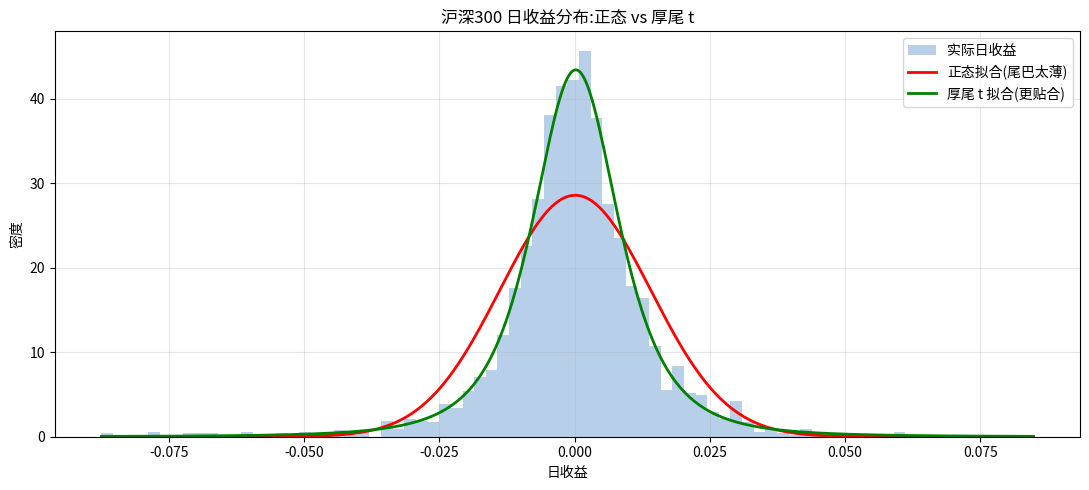

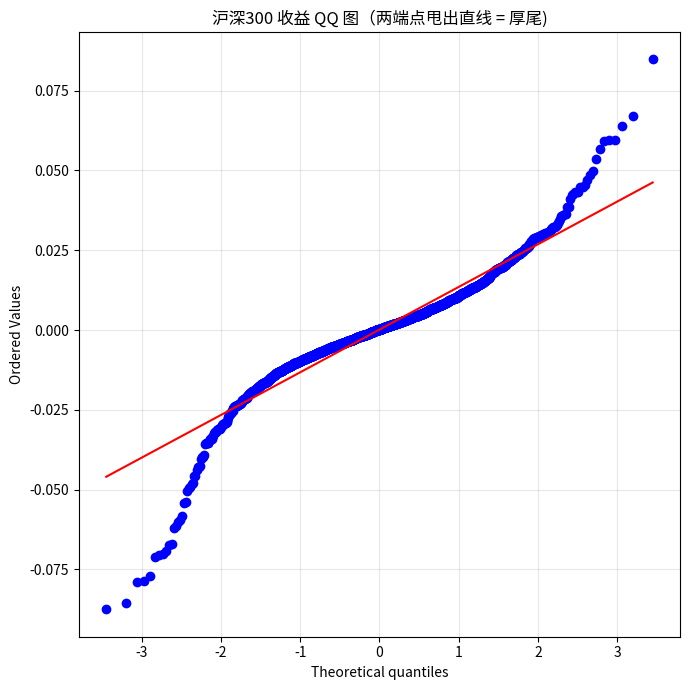

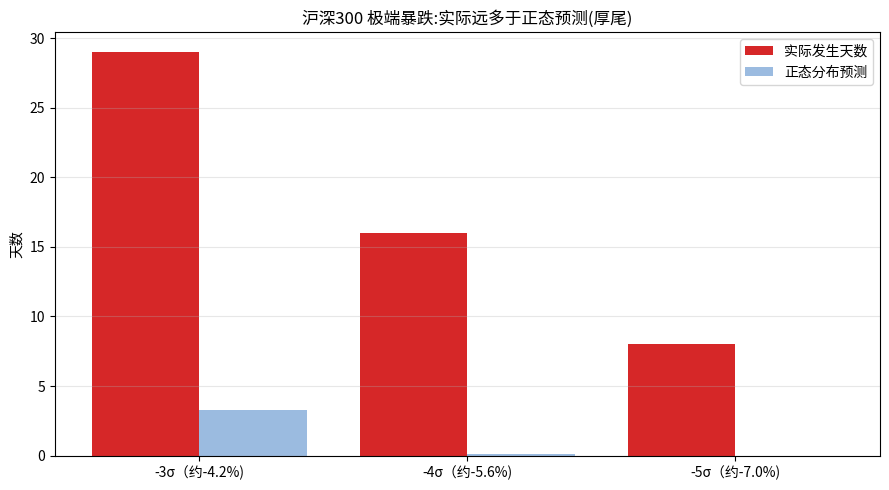

In [2]:
# day_048_scipy_stats.py — SciPy 统计工具箱:拟合分布 / 正态 vs 厚尾 t 分布 / KS 检验 / 极端事件
# 一个反直觉真相:股票收益不是教科书的『正态钟形曲线』,尾巴特别厚,暴涨暴跌比理论常见得多
# 真名上屏:scipy.stats.norm / scipy.stats.t / stats.kstest / scipy.integrate.quad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
import baostock as bs

def _data_path(_name):
    # 铁律62:data/ 放在 notebook 文件夹里。仓库根(run_lab)存取 out/notebook/data/;
    # 原版 notebook 在 out/notebook/ 用 data/;中国版在 out/notebook/cn/ 用 ../data/
    from pathlib import Path as _P
    _here = _P.cwd()
    for _b in [_here/'data', _here/'..'/'data', _here/'out'/'notebook'/'data', _here/'..'/'..'/'data', _here/'..'/'..'/'..'/'data']:
        if (_b/_name).exists():
            return str(_b/_name)
    if (_here/'out'/'notebook').exists():
        _t = _here/'out'/'notebook'/'data'
    elif _here.name == 'cn':
        _t = _here/'..'/'data'
    else:
        _t = _here/'data'
    _t.mkdir(parents=True, exist_ok=True)
    return str(_t/_name)

pd.set_option('display.width', 160)
plt.rcParams['axes.unicode_minus'] = False
CODE, NAME = 'sh.000300', '沪深300'
START, END = '2015-01-01', '2024-12-31'

# ==== 0. 拉沪深300指数十年日线:CSV 优先,baostock 兜底,拉完存 CSV ====
print('==== 0. 拉沪深300十年日线,算日收益 ====')
import os as _os
_csv = _data_path('D048_scipy.csv')
if _os.path.exists(_csv):
    px = pd.read_csv(_csv)
    print(f'从本地 CSV 读取:{_csv}')
else:
    lg = bs.login()
    if lg.error_code != '0':
        raise RuntimeError(f'baostock 登录失败:{lg.error_msg}')
    rs = bs.query_history_k_data_plus(CODE, 'date,close', start_date=START, end_date=END,
                                      frequency='d')
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    bs.logout()
    px = pd.DataFrame(rows, columns=['date', 'close'])
    px.to_csv(_csv, index=False)
    print(f'已从 baostock 拉取并存成 CSV:{_csv}')
px['date'] = pd.to_datetime(px['date'])
px['close'] = pd.to_numeric(px['close'])
px = px.set_index('date').sort_index()
ret = px['close'].pct_change().dropna()
print(f'{NAME} {len(ret)} 个交易日的日收益,均值 {ret.mean()*100:.3f}%,标准差 {ret.std()*100:.2f}%')

# ==== 1. 把收益堆成直方图,看它是什么形状 ====
print('\n==== 1. 收益分布的形状(直方图)====')
mu, sigma = ret.mean(), ret.std()
print(f'如果是教科书的正态分布,99.7% 的日子应落在 ±3 个标准差(约 ±{3*sigma*100:.1f}%)以内')

# ==== 2. 用 scipy 拟合两种分布:正态 vs 厚尾 t 分布 ====
print('\n==== 2. scipy 拟合:正态分布 vs 厚尾 t 分布 ====')
# 正态分布:两个参数(中心、宽度)
mu_n, sd_n = stats.norm.fit(ret)
# t 分布:多一个『自由度』参数,自由度越小尾巴越厚
df_t, loc_t, scale_t = stats.t.fit(ret)
print(f'正态拟合:中心={mu_n*100:.3f}%  宽度={sd_n*100:.2f}%')
print(f't 分布拟合:自由度={df_t:.2f}（越小尾巴越厚,<10 就是明显厚尾)')

# ==== 3. KS 检验:用数字判断『像不像』某个分布 ====
print('\n==== 3. KS 检验(p 值越大越像;<0.05 基本可以否掉)====')
ks_norm = stats.kstest(ret, 'norm', args=(mu_n, sd_n))
ks_t = stats.kstest(ret, 't', args=(df_t, loc_t, scale_t))
print(f'像正态吗?p 值 = {ks_norm.pvalue:.4f}')
print(f'像厚尾 t 吗?p 值 = {ks_t.pvalue:.4f}')

# ==== 4. 厚尾的代价:实际极端暴跌天数 vs 正态预测 ====
print('\n==== 4. 极端暴跌:实际发生 vs 正态分布的预测 ====')
rows_cmp = []
for k in (3, 4, 5):
    thresh = mu - k * sigma
    actual = int((ret < thresh).sum())
    # 正态分布预测的概率,用 scipy.integrate.quad 对正态曲线尾部积分得到
    p_normal, _ = integrate.quad(lambda x: stats.norm.pdf(x, mu_n, sd_n), -np.inf, thresh)
    expected = p_normal * len(ret)
    rows_cmp.append({'跌幅门槛': f'-{k}σ（约{thresh*100:.1f}%)',
                     '实际天数': actual, '正态预测天数': round(expected, 2)})
cmp = pd.DataFrame(rows_cmp)
print(cmp.to_string(index=False))
print('实际的极端暴跌天数远多于正态分布的预测 , 这就是厚尾,黑天鹅是常客不是稀客')

# ==== 5. 画图:直方图 + 两条拟合曲线 ====
print('\n==== 5. 画三张图:分布拟合 / QQ图 / 极端事件对比 ====')
x = np.linspace(ret.min(), ret.max(), 400)
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(ret, bins=80, density=True, color='#9bbbe0', alpha=0.7, label='实际日收益')
ax.plot(x, stats.norm.pdf(x, mu_n, sd_n), 'r-', lw=2, label='正态拟合(尾巴太薄)')
ax.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), 'g-', lw=2, label='厚尾 t 拟合(更贴合)')
ax.set_title(f'{NAME} 日收益分布:正态 vs 厚尾 t'); ax.set_xlabel('日收益'); ax.set_ylabel('密度')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('dist.png', dpi=120)

# QQ 图:点偏离直线越远,尾巴越厚
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(ret, dist='norm', plot=ax)
ax.set_title(f'{NAME} 收益 QQ 图（两端点甩出直线 = 厚尾)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('qq.png', dpi=120)

# 极端暴跌:实际 vs 正态预测 柱状对比
fig, ax = plt.subplots(figsize=(9, 5))
xlab = cmp['跌幅门槛']; xpos = np.arange(len(xlab))
ax.bar(xpos - 0.2, cmp['实际天数'], width=0.4, label='实际发生天数', color='#d62728')
ax.bar(xpos + 0.2, cmp['正态预测天数'], width=0.4, label='正态分布预测', color='#9bbbe0')
ax.set_xticks(xpos); ax.set_xticklabels(xlab)
ax.set_title(f'{NAME} 极端暴跌:实际远多于正态预测(厚尾)'); ax.set_ylabel('天数')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.savefig('extreme.png', dpi=120)

print('\n[done] 分布拟合 + KS 检验 + 极端事件对比完成,3 张图已生成')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 指数 | sh.000300 | 沪深30010 年日收益,拟合正态 vs 厚尾 t 分布,KS 检验看哪个更贴合 |
| 风险认知 |  | 数一数实际跌超 3/4/5 个标准差的天数,和正态预测对比,亲眼看到厚尾的代价 |
| 尾部概率 |  | 用 integrate.quad 对分布尾部积分,算出『跌超某幅度』的真实概率,别用正态低估 |
| 组合优化 |  | 用 scipy.optimize.minimize 求一组让组合波动最小的权重(同一个百宝箱里的工具) |


## 常见坑

### ⚠ 01. 默认收益是正态,严重低估风险

图省事假设收益服从正态分布,算出来的极端风险会被大大低估,正态认为几百年一遇的暴跌,现实几年就来。做风险管理一定要正视厚尾,用 t 分布等更贴合的工具,或直接看历史上真实发生过多少次极端行情。

### ⚠ 02. 把『小概率』当成『不会发生』

老钱的错就在这:小概率不等于零概率,更不等于轮不到你。在厚尾的真实市场里,极端事件还比正态算的更频繁。永远给极端行情留余地,别上满杠杆、别不设止损,因为那个『不可能』迟早会来。

### ⚠ 03. 拟合了分布却不做检验

随手用正态或 t 拟合一下就当结论,不靠谱。一定要用 KS 检验等手段看 p 值,用数字判断到底像不像。否则你可能在一个根本不贴合的分布上,推出一堆似是而非的结论。

### ⚠ 04. 样本太少就下分布结论

尾巴上的极端事件本来就稀少,如果只拿一两年、几百个交易日的数据去研究尾部,样本太少,结论会很不稳。研究厚尾尽量用足够长的历史(本节用了10 年),样本越多对尾巴的刻画越可靠。

### ⚠ 05. scipy.stats 的参数顺序搞混

stats.t.fit 返回的是(自由度, 中心, 宽度)三个参数,顺序和 norm 的(中心, 宽度)不一样;调 pdf/kstest 时参数要按对应顺序传回去。传错顺序画出来的曲线会完全不对。拟合完先把参数打印出来核对一下。

## 实战 SOP · 用统计分布看风险的几条规矩

1. 默认收益不是正态:真实市场厚尾,极端行情远比钟形曲线预测的频繁
2. 小概率 ≠ 不会发生,永远给极端行情留余地(别满杠杆、别不设止损)
3. 拟合分布后一定用 KS 检验等手段看 p 值,用数字判断像不像,别凭感觉
4. 研究尾部要用足够长的历史样本,样本太少对尾巴的刻画不可靠
5. 记牢 SciPy 各工具:stats 管分布、optimize 管求最优、integrate 管数值积分

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 分布 = 把一堆收益按大小堆成的山丘形状:中间高(常态)、两边尾巴(极端)。
3. 正态分布是漂亮的钟形山,但它假设极端事件极罕见,容易让人低估风险。
4. 厚尾 = 真实收益的尾巴比正态厚,暴涨暴跌远比预测频繁;t 分布能更好刻画它。
5. scipy.stats 帮你 fit 拟合(自动找最贴合的参数)+ KS 检验(用 p 值判断像不像)。
6. 数一数实际极端暴跌天数 vs 正态预测,亲眼看到厚尾,黑天鹅是常客不是稀客。
7. SciPy 百宝箱还有 optimize 求最优、integrate 数值积分,量化里反复要用。

## 自测题

**Q1.** 用『山丘』打比方,解释什么是收益的『分布』,以及山头和尾巴各代表什么。

**Q2.** 什么叫『厚尾』?老钱觉得『跌停轮不到我』却3 年碰四回,和厚尾有什么关系?

**Q3.** fit 拟合和 KS 检验各帮你做什么?为什么拟合完还一定要做检验?

**Q4.** 为什么假设收益服从正态分布会低估风险?这对你的仓位和止损有什么启发?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 049 · statsmodels 回归** (statsmodels)

看清了收益的厚尾分布,下一节我们升级统计武器:用 statsmodels 做回归分析,亲手跑一个经典的多因子模型,看看一只股票的涨跌,到底有多少能被市场、规模、价值这些共同因子解释,又有多少是它自己的真本事。

## 推荐阅读

- Taleb《The Black Swan》(2007/Random House)— 厚尾与极端事件的思想经典,讲透为什么别用正态看世界。
- Mandelbrot & Hudson《The (Mis)Behavior of Markets》(2004/Basic Books)— 厚尾分形之父亲述市场为何远比钟形曲线狂野。
- Cont《Empirical properties of asset returns》(2001/Quantitative Finance)— 收益厚尾、波动聚集等经验事实的权威综述论文。
- SciPy 官方文档 scipy.stats(docs.scipy.org)— 分布拟合、KS 检验、optimize、integrate 的函数手册。
- McNeil, Frey & Embrechts《Quantitative Risk Management》(2015/Princeton)— 用厚尾分布做风险管理的标准教材。